In [7]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


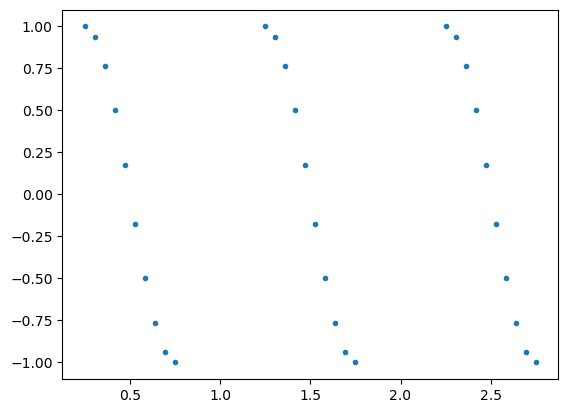

In [8]:
# a = np.linspace(0, 1, 10)
# b = np.linspace(3, 4, 10)
# c = np.linspace(6, 9, 10)
# d = np.linspace(10, 10.5, 10)
# e = np.linspace(12, 12.5, 10)
# t = np.concatenate([a, b, c, d, e])

t = np.concatenate([np.linspace(t0 + 0.25, t0 + 0.75, 10) for t0 in range(3)])
# t = np.concatenate([np.linspace(t0, t0 + 0.5, 10) for t0 in range(3)])


x = np.sin(2*np.pi*t)

dxdt = 2*np.pi*np.cos(2*np.pi*t)

plt.plot(t, x, '.')

In [9]:
def split_data(t, x, max_diff):
    """split up the data into disjoint numpy arrays if the time difference is greater than max_width"""
    t_diff = np.diff(t)
    
    # find the indices where the time difference is greater than max_width
    # each split index is the index of the last element of the previous split
    split_indices = np.where(t_diff > max_diff)[0]
    # add the start and end indices to the split indices
    # -1 is added to the start index to include the first element
    split_indices = np.concatenate([[-1], split_indices, [len(t)]])

    t_split = []
    x_split = []
    for i in range(len(split_indices)-1):
        start = split_indices[i] + 1
        end = split_indices[i+1] + 1
        t_split.append(t[start:end]) # recall that the end index is exclusive
        x_split.append(x[start:end]) # recall that the end index is exclusive
    
    return t_split, x_split


def split_process_data(t, x, max_diff, f):
    t_split, x_split = split_data(t, x, max_diff)
    
    f_split = []
    for i in range(len(t_split)):
        f_split.append(f(x_split[i], t_split[i]))
    
    return np.concatenate(f_split)


# t_split, x_split = split_data(t, x, 0.5)

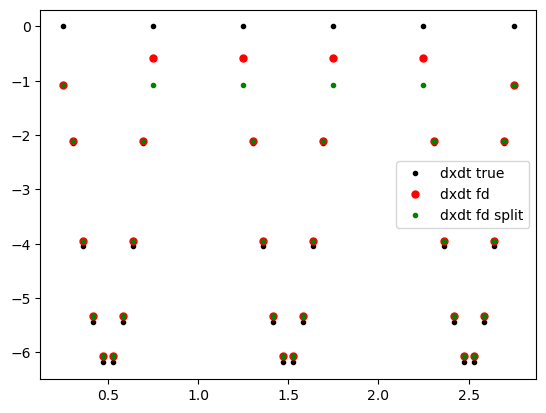

In [10]:
dxdt_fd = dxdt_finite_difference_1d(x, t)
dxdt_fd_split = split_process_data(t, x, 0.3, dxdt_finite_difference_1d)

# plt.plot(t, x, '.-', label='x')
plt.plot(t, dxdt, 'k.', label='dxdt true')
plt.plot(t, dxdt_fd, 'r.', label='dxdt fd', markersize=10)
plt.plot(t, dxdt_fd_split, 'g.', label='dxdt fd split')
plt.legend()